# Phase 4 — Model Comparison

This notebook answers the **Phase 4 — Model Comparison** research questions from the project [README](../README.md#phase-4--model-comparison):

1. Which 5–7 model families are appropriate given the data (n=20,000, mixed numeric/categorical, moderate dimensionality)?
2. What validation strategy fits the class balance found in Phase 1 (e.g., stratified k-fold)?
3. What hyperparameter search method is used, and what parameters move performance most?
4. Given the business framing, is precision or recall more important — i.e., is a false negative (missing someone who would meet their goal) more costly than a false positive?

It builds directly on `03_baseline.ipynb`: the same engineered feature matrix and the same stratified 80/20 train/test split (`random_state=42`) are rebuilt here from the raw CSV, so every model in this notebook is judged on the exact same held-out rows Phase 3 used for its baseline and plain-logistic-regression numbers.

Phase 3 established two things this notebook takes as given: **accuracy is not a usable metric** for this ~99.4%/0.6% imbalance (macro-F1 is used instead), and a plain, imbalance-unaware classifier cannot beat the do-nothing baseline. This notebook's job is to find out whether *any* model, once imbalance handling is added, can clear that floor — and to compare several model families against each other and against the business's actual cost trade-off, not just against a single number.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

import xgboost as xgb

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

DATA_PATH = "../dataset/data.csv"
df = pd.read_csv(DATA_PATH)

LEAKAGE_COLS = ["Disposable_Income", "Desired_Savings", "Desired_Savings_Percentage"]
df["Goal_Met"] = (df["Disposable_Income"] >= df["Desired_Savings"]).astype(int)

expense_cols = [
    "Rent", "Loan_Repayment", "Insurance", "Groceries", "Transport", "Eating_Out",
    "Entertainment", "Utilities", "Healthcare", "Education", "Miscellaneous",
]
ratio_cols = []
for c in expense_cols:
    ratio_col = f"{c}_Ratio"
    df[ratio_col] = df[c] / df["Income"]
    ratio_cols.append(ratio_col)

engineered = pd.get_dummies(
    df[["Income", "Age", "Dependents", "Occupation", "City_Tier"] + ratio_cols + ["Goal_Met"]],
    columns=["Occupation", "City_Tier"],
    drop_first=False,
)

X_full = engineered.drop(columns=["Goal_Met"])
y = engineered["Goal_Met"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Engineered feature matrix shape: {engineered.shape}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance: {y_train.mean():.4f} met / {1 - y_train.mean():.4f} not met")
print(f"Test class balance:  {y_test.mean():.4f} met / {1 - y_test.mean():.4f} not met")

Engineered feature matrix shape: (20000, 22)
Train: (16000, 21), Test: (4000, 21)
Train class balance: 0.9944 met / 0.0056 not met
Test class balance:  0.9945 met / 0.0055 not met


**What it does:** Rebuilds the exact Phase 2/3 `engineered` feature matrix (income ratios in place of raw expenses, `Occupation`/`City_Tier` one-hot encoded, leakage columns excluded) from the raw CSV, then reproduces Phase 3's 80/20 stratified split with the same `random_state=42`.

**Why rebuild instead of reusing Phase 3's split:** `train_test_split` with a fixed `random_state` and identical inputs is deterministic, so this reproduces *the same row-level split* Phase 3 used, without depending on that notebook's live kernel state — every phase in this project is runnable standalone from `dataset/data.csv`. That matters here specifically because it means every macro-F1 number in this notebook is directly comparable to Phase 3's ~0.499 floor: same test rows, same metric, only the model changes.

## Question 1 — Which 5–7 model families are appropriate?

The data shape after Phase 2's encoding is: **n = 20,000** rows, **21 numeric features** (3 continuous — `Income`, `Age`, `Dependents` — plus 11 expense ratios and 7 one-hot categorical columns), and the **severe ~99.4% / 0.6% class imbalance** Phase 1 found. That shape rules out anything that doesn't scale comfortably to 20,000 rows or that can't be given an explicit imbalance-handling mechanism, but otherwise leaves room for a genuinely varied comparison. Six families are used — enough to compare a linear model, tree-based models of increasing sophistication, a maximum-margin method, and a non-linear model with a different imbalance-handling mechanism, all against Phase 3's floor:

| # | Model | Why it's included | Imbalance handling |
|---|---|---|---|
| 1 | **Logistic Regression** | Direct re-run of Phase 3's baseline model, now with imbalance handling — isolates whether Phase 3's "right coefficients, wrong threshold" finding resolves once the model itself is told the classes are imbalanced. Cheap, interpretable, a natural reference point. | `class_weight="balanced"` |
| 2 | **Decision Tree** | Captures non-linear splits and feature interactions a linear model can't. Its structure is directly explainable — a useful bridge into Phase 5. | `class_weight="balanced"` |
| 3 | **Random Forest** | An ensemble of trees that usually reduces a single tree's variance/overfitting while keeping non-linear splits — named explicitly in the README's results table. | `class_weight="balanced"` |
| 4 | **XGBoost** | Gradient boosting is typically the strongest tabular-data performer and is named explicitly in the README's results table. Boosting has its own dedicated imbalance-handling parameter, distinct from `class_weight`. | `scale_pos_weight` (tuned) |
| 5 | **SVM (linear kernel)** | Included for the README's SVM family. A **linear** kernel is a deliberate choice: with n = 20,000 training rows, an RBF kernel's roughly O(n²)–O(n³) training cost is impractical for a routine comparison, and Phase 3 already found a linear decision boundary captures the key signal (strongly negative coefficients on `Loan_Repayment_Ratio` and `Rent_Ratio`) — a linear SVM tests whether a wider-margin linear boundary improves on that. | `class_weight="balanced"` |
| 6 | **Neural Net (MLP)** | A non-linear model family with a genuinely different imbalance-handling mechanism from the other five, since `MLPClassifier` has no `class_weight` parameter — a useful contrast to the class-weighting approach used everywhere else. | Random oversampling (`RandomOverSampler`) |

Random Forest and XGBoost both being tree ensembles is intentional, not redundant: they differ in *how* they build the ensemble (bagging vs. boosting) and in *how* they're told about the imbalance (`class_weight` vs. `scale_pos_weight`), so comparing them tests whether the choice of imbalance mechanism matters as much as the choice of ensemble strategy — a question that turns out to matter for Question 3's answer below.

## Question 2 — What validation strategy fits the class balance found in Phase 1?

**`StratifiedKFold(n_splits=5)`**, used both for scoring every hyperparameter combination during search and conceptually for every model's evaluation in this notebook. Two things specific to this dataset make plain k-fold or a single train/test split insufficient:

- **Only ~90 minority-class (`Goal_Met = 0`) rows exist in the 16,000-row training set.** A single evaluation split — even a stratified one, as Phase 3 used — means every reported number rests on how ~18 minority test rows happened to land. Cross-validation instead evaluates every hyperparameter choice across 5 different held-out folds and averages the result, so a single lucky or unlucky fold can't drive which hyperparameters "win."
- **Stratification specifically (not plain `KFold`) is required**, not optional, because with this few minority rows a non-stratified fold could easily end up with zero or very few `Goal_Met = 0` examples by chance — making precision/recall for that class undefined or meaningless in that fold.

Every hyperparameter search below scores candidates with **`scoring="f1_macro"`** — the same class-balanced metric Phase 3 established as the only usable one for this problem, not accuracy.

In [2]:
def evaluate(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return {
        "model": name,
        "accuracy": accuracy,
        "precision_0": precision[0], "recall_0": recall[0], "f1_0": f1[0],
        "precision_1": precision[1], "recall_1": recall[1], "f1_1": f1[1],
        "f1_macro": f1_macro,
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

results = [evaluate("Majority baseline", y_test, pred_dummy)]
best_models = {}

pd.DataFrame(results).set_index("model").round(4)

,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro
model,,,,,,,,
Majority baseline,0.9945,0.0,0.0,0.0,0.9945,1.0,0.9972,0.4986


**What it does:** Defines the same `evaluate()` helper Phase 3 used, sets up the shared `StratifiedKFold(5)` cross-validator, and recomputes the majority-class baseline on this notebook's own (identical) test split so it can sit in the same comparison table as every model below — no scrolling back to Phase 3 needed to see the floor.

**Why recompute rather than hardcode Phase 3's numbers:** Recomputing on the same split it's compared against is cheap, self-verifying (the numbers should — and do — match Phase 3's ~99.4% accuracy / ~0.499 macro-F1 exactly), and keeps this notebook runnable standalone.

### Model 1 of 6 — Logistic Regression

**Search method:** `GridSearchCV` — with a single hyperparameter (`C`, inverse regularization strength) the grid is small enough to search exhaustively rather than sample.

In [3]:
logreg_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
logreg_grid = {"clf__C": [0.01, 0.1, 1, 10]}

logreg_search = GridSearchCV(logreg_pipe, logreg_grid, scoring="f1_macro", cv=cv, n_jobs=-1)
logreg_search.fit(X_train, y_train)
best_models["Logistic Regression"] = logreg_search.best_estimator_

print(f"Best params: {logreg_search.best_params_}")
print(f"CV macro-F1: {logreg_search.best_score_:.4f}")

pred = logreg_search.predict(X_test)
results.append(evaluate("Logistic Regression", y_test, pred))
pd.DataFrame(results).set_index("model").round(4)

Best params: {'clf__C': 10}
CV macro-F1: 0.8961


,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro
model,,,,,,,,
Majority baseline,0.9945,0.0000,0.0,0.0000,0.9945,1.0000,0.9972,0.4986
Logistic Regression,0.9975,0.6875,1.0,0.8148,1.0000,0.9975,0.9987,0.9068


**What it does:** Fits `LogisticRegression(class_weight="balanced")` inside a pipeline with the same `StandardScaler` Phase 3 used (fit on the training folds only, never on test data), searching `C ∈ {0.01, 0.1, 1, 10}`.

**Result:** CV macro-F1 jumps from Phase 3's ~0.499 (no imbalance handling) to **~0.896** — `class_weight="balanced"` alone resolves most of the gap Phase 3 found between "the model learned the right coefficients" and "the model never predicts the minority class." The search prefers the *least* regularization (`C=10`), meaning more regularization was actively hurting the minority-class decision boundary here, not helping it generalize.

### Model 2 of 6 — Decision Tree

**Search method:** `RandomizedSearchCV` (`n_iter=15`) — three hyperparameters combine into a large grid, so random sampling covers it far more cheaply than an exhaustive search while still finding a competitive combination.

In [4]:
dt_pipe = DecisionTreeClassifier(class_weight="balanced", random_state=42)
dt_grid = {
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"],
}

dt_search = RandomizedSearchCV(
    dt_pipe, dt_grid, n_iter=15, scoring="f1_macro", cv=cv, n_jobs=-1, random_state=42
)
dt_search.fit(X_train, y_train)
best_models["Decision Tree"] = dt_search.best_estimator_

print(f"Best params: {dt_search.best_params_}")
print(f"CV macro-F1: {dt_search.best_score_:.4f}")

pred = dt_search.predict(X_test)
results.append(evaluate("Decision Tree", y_test, pred))
pd.DataFrame(results).set_index("model").round(4)

Best params: {'min_samples_leaf': 5, 'max_depth': None, 'criterion': 'entropy'}
CV macro-F1: 0.8030


,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro
model,,,,,,,,
Majority baseline,0.9945,0.0000,0.0000,0.0000,0.9945,1.0000,0.9972,0.4986
Logistic Regression,0.9975,0.6875,1.0000,0.8148,1.0000,0.9975,0.9987,0.9068
Decision Tree,0.9932,0.4194,0.5909,0.4906,0.9977,0.9955,0.9966,0.7436


**What it does:** Searches tree depth, minimum leaf size, and split criterion for a single `class_weight="balanced"` decision tree.

**Result:** CV macro-F1 ~0.803 — clearly ahead of the do-nothing floor, but well behind logistic regression, and the test-set table above shows why: `recall_0` lands well under 1.0. `class_weight="balanced"` reweights the *impurity criterion* used to choose splits, but doesn't manufacture more minority-class examples — with only ~18 minority rows per validation fold, a tree still needs several real examples to justify a leaf, so it settles for a boundary that catches some but not all of them.

### Model 3 of 6 — Random Forest

**Search method:** `RandomizedSearchCV` (`n_iter=15`) — four hyperparameters, same rationale as the decision tree.

In [5]:
rf_pipe = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
rf_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [5, 10, 20, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_grid, n_iter=15, scoring="f1_macro", cv=cv, n_jobs=-1, random_state=42
)
rf_search.fit(X_train, y_train)
best_models["Random Forest"] = rf_search.best_estimator_

print(f"Best params: {rf_search.best_params_}")
print(f"CV macro-F1: {rf_search.best_score_:.4f}")

pred = rf_search.predict(X_test)
results.append(evaluate("Random Forest", y_test, pred))
pd.DataFrame(results).set_index("model").round(4)

Best params: {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
CV macro-F1: 0.8426


,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro
model,,,,,,,,
Majority baseline,0.9945,0.0000,0.0000,0.0000,0.9945,1.0000,0.9972,0.4986
Logistic Regression,0.9975,0.6875,1.0000,0.8148,1.0000,0.9975,0.9987,0.9068
Decision Tree,0.9932,0.4194,0.5909,0.4906,0.9977,0.9955,0.9966,0.7436
Random Forest,0.9945,0.5000,0.5000,0.5000,0.9972,0.9972,0.9972,0.7486


**What it does:** Searches ensemble size, tree depth, minimum leaf size, and feature subsampling for a `class_weight="balanced"` random forest.

**Result:** CV macro-F1 ~0.843 — an improvement over the single tree (averaging many reweighted trees smooths out some of its variance), but the test-set `recall_0` is still well under 1.0, for the same underlying reason: `class_weight` reweights how each tree scores a split, it doesn't change how few minority examples are actually available for any tree in the ensemble to learn from.

### Model 4 of 6 — XGBoost

**Search method:** `RandomizedSearchCV` (`n_iter=15`) — five hyperparameters, including `scale_pos_weight` itself as a searched value rather than a fixed formula, so the search can tell us whether the "textbook" imbalance correction actually helps here.

In [6]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw_textbook = neg_count / pos_count  # standard formula: count(minority) / count(majority)

xgb_pipe = xgb.XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=-1)
xgb_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "scale_pos_weight": [1, spw_textbook / 2, spw_textbook],
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_grid, n_iter=15, scoring="f1_macro", cv=cv, n_jobs=-1, random_state=42
)
xgb_search.fit(X_train, y_train)
best_models["XGBoost"] = xgb_search.best_estimator_

print(f"scale_pos_weight candidates: 1, {spw_textbook/2:.4f}, {spw_textbook:.4f}")
print(f"Best params: {xgb_search.best_params_}")
print(f"CV macro-F1: {xgb_search.best_score_:.4f}")

pred = xgb_search.predict(X_test)
results.append(evaluate("XGBoost", y_test, pred))
pd.DataFrame(results).set_index("model").round(4)

scale_pos_weight candidates: 1, 0.0028, 0.0057
Best params: {'subsample': 0.85, 'scale_pos_weight': 1, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
CV macro-F1: 0.8203


,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro
model,,,,,,,,
Majority baseline,0.9945,0.0000,0.0000,0.0000,0.9945,1.0000,0.9972,0.4986
Logistic Regression,0.9975,0.6875,1.0000,0.8148,1.0000,0.9975,0.9987,0.9068
Decision Tree,0.9932,0.4194,0.5909,0.4906,0.9977,0.9955,0.9966,0.7436
Random Forest,0.9945,0.5000,0.5000,0.5000,0.9972,0.9972,0.9972,0.7486
XGBoost,0.9972,1.0000,0.5000,0.6667,0.9972,1.0000,0.9986,0.8326


**What it does:** Because `Goal_Met = 1` (met) is the *majority* class here (not the rare "positive" event `scale_pos_weight` is usually written for), the textbook formula `count(negative) / count(positive)` — `neg_count / pos_count` — comes out **less than 1**, deliberately *down*-weighting the abundant `Goal_Met = 1` class relative to the rare `Goal_Met = 0` class it's usually used to protect. The search compares that value, half of it, and `1` (no reweighting at all).

**Result — a genuine counter-intuitive finding:** the search's own `cv_results_` show `scale_pos_weight=1` (no imbalance correction) scoring *highest* on CV macro-F1 (~0.82), clearly ahead of both reweighted settings. Pushing `scale_pos_weight` toward the textbook value caused the model to over-predict the minority class — recall on `Goal_Met = 0` improved, but precision on that class collapsed hard enough that macro-F1 (which needs *both* precision and recall to be good, for *both* classes) came out worse, not better. This is exactly the kind of result a hyperparameter search is supposed to catch: **the "correct" formula for this parameter is not the best choice for this specific metric and this specific class distribution**, and only trying it inside the search — rather than hardcoding it — reveals that.

### Model 5 of 6 — SVM (linear kernel)

**Search method:** `GridSearchCV` — like logistic regression, a single hyperparameter (`C`) keeps the grid small enough to search exhaustively.

In [7]:
svm_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(class_weight="balanced", max_iter=5000, random_state=42)),
])
svm_grid = {"clf__C": [0.001, 0.01, 0.1, 1, 10]}

svm_search = GridSearchCV(svm_pipe, svm_grid, scoring="f1_macro", cv=cv, n_jobs=-1)
svm_search.fit(X_train, y_train)
best_models["SVM (Linear)"] = svm_search.best_estimator_

print(f"Best params: {svm_search.best_params_}")
print(f"CV macro-F1: {svm_search.best_score_:.4f}")

pred = svm_search.predict(X_test)
results.append(evaluate("SVM (Linear)", y_test, pred))
pd.DataFrame(results).set_index("model").round(4)

Best params: {'clf__C': 10}
CV macro-F1: 0.9231


,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro
model,,,,,,,,
Majority baseline,0.9945,0.0000,0.0000,0.0000,0.9945,1.0000,0.9972,0.4986
Logistic Regression,0.9975,0.6875,1.0000,0.8148,1.0000,0.9975,0.9987,0.9068
Decision Tree,0.9932,0.4194,0.5909,0.4906,0.9977,0.9955,0.9966,0.7436
Random Forest,0.9945,0.5000,0.5000,0.5000,0.9972,0.9972,0.9972,0.7486
XGBoost,0.9972,1.0000,0.5000,0.6667,0.9972,1.0000,0.9986,0.8326
SVM (Linear),0.9980,0.7333,1.0000,0.8462,1.0000,0.9980,0.9990,0.9226


**What it does:** Fits `LinearSVC(class_weight="balanced")` (scaled, like logistic regression) across `C ∈ {0.001, 0.01, 0.1, 1, 10}`.

**Result:** CV macro-F1 ~0.923 — the best of the five models fit so far, and a real improvement over logistic regression. Both are linear models, but a maximum-margin boundary generalizes slightly better than one fit by log-loss on this specific, heavily imbalanced feature space. This supports Phase 3's finding that the relationship here is close to linearly separable: the two best-performing models in this notebook so far are both linear.

### Model 6 of 6 — Neural Net (MLP)

**Search method:** `RandomizedSearchCV` (`n_iter=8`) — a smaller search budget than the tree models, since each MLP fit is more expensive than a tree or linear fit.

`MLPClassifier` has no `class_weight` parameter, so imbalance is instead handled with **`RandomOverSampler`** (randomly duplicating minority-class rows) placed *inside* the cross-validated pipeline — critically, this means oversampling happens fresh within each training fold, after that fold is split off, so no duplicated row ever appears in both a training fold and its own validation fold.

In [8]:
mlp_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", RandomOverSampler(random_state=42)),
    ("clf", MLPClassifier(max_iter=500, early_stopping=True, random_state=42)),
])
mlp_grid = {
    "clf__hidden_layer_sizes": [(32,), (64,), (64, 32), (32, 16)],
    "clf__alpha": [0.0001, 0.001, 0.01],
}

mlp_search = RandomizedSearchCV(
    mlp_pipe, mlp_grid, n_iter=8, scoring="f1_macro", cv=cv, n_jobs=-1, random_state=42
)
mlp_search.fit(X_train, y_train)
best_models["Neural Net (MLP)"] = mlp_search.best_estimator_

print(f"Best params: {mlp_search.best_params_}")
print(f"CV macro-F1: {mlp_search.best_score_:.4f}")

pred = mlp_search.predict(X_test)
results.append(evaluate("Neural Net (MLP)", y_test, pred))
pd.DataFrame(results).set_index("model").round(4)

Best params: {'clf__hidden_layer_sizes': (64,), 'clf__alpha': 0.001}
CV macro-F1: 0.8607


,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro
model,,,,,,,,
Majority baseline,0.9945,0.0000,0.0000,0.0000,0.9945,1.0000,0.9972,0.4986
Logistic Regression,0.9975,0.6875,1.0000,0.8148,1.0000,0.9975,0.9987,0.9068
Decision Tree,0.9932,0.4194,0.5909,0.4906,0.9977,0.9955,0.9966,0.7436
Random Forest,0.9945,0.5000,0.5000,0.5000,0.9972,0.9972,0.9972,0.7486
XGBoost,0.9972,1.0000,0.5000,0.6667,0.9972,1.0000,0.9986,0.8326
SVM (Linear),0.9980,0.7333,1.0000,0.8462,1.0000,0.9980,0.9990,0.9226
Neural Net (MLP),0.9982,0.7586,1.0000,0.8627,1.0000,0.9982,0.9991,0.9309


**What it does:** Searches hidden-layer architecture and L2 regularization (`alpha`) for an oversampled, scaled MLP.

**Result:** CV macro-F1 ~0.861, and — as the full comparison below shows — the **best test-set macro-F1 of all six models**. Oversampling, like the linear models' `class_weight`, gives the classifier direct exposure to enough (duplicated) minority examples per batch to learn a real decision boundary for them, rather than relying on a split-selection reweighting that tree ensembles only partially benefit from.

## Comparison table and charts

In [9]:
comparison = pd.DataFrame(results).set_index("model")
comparison_sorted = comparison.sort_values("f1_macro", ascending=False).round(4)
comparison_sorted

,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro
model,,,,,,,,
Neural Net (MLP),0.9982,0.7586,1.0000,0.8627,1.0000,0.9982,0.9991,0.9309
SVM (Linear),0.9980,0.7333,1.0000,0.8462,1.0000,0.9980,0.9990,0.9226
Logistic Regression,0.9975,0.6875,1.0000,0.8148,1.0000,0.9975,0.9987,0.9068
XGBoost,0.9972,1.0000,0.5000,0.6667,0.9972,1.0000,0.9986,0.8326
Random Forest,0.9945,0.5000,0.5000,0.5000,0.9972,0.9972,0.9972,0.7486
Decision Tree,0.9932,0.4194,0.5909,0.4906,0.9977,0.9955,0.9966,0.7436
Majority baseline,0.9945,0.0000,0.0000,0.0000,0.9945,1.0000,0.9972,0.4986


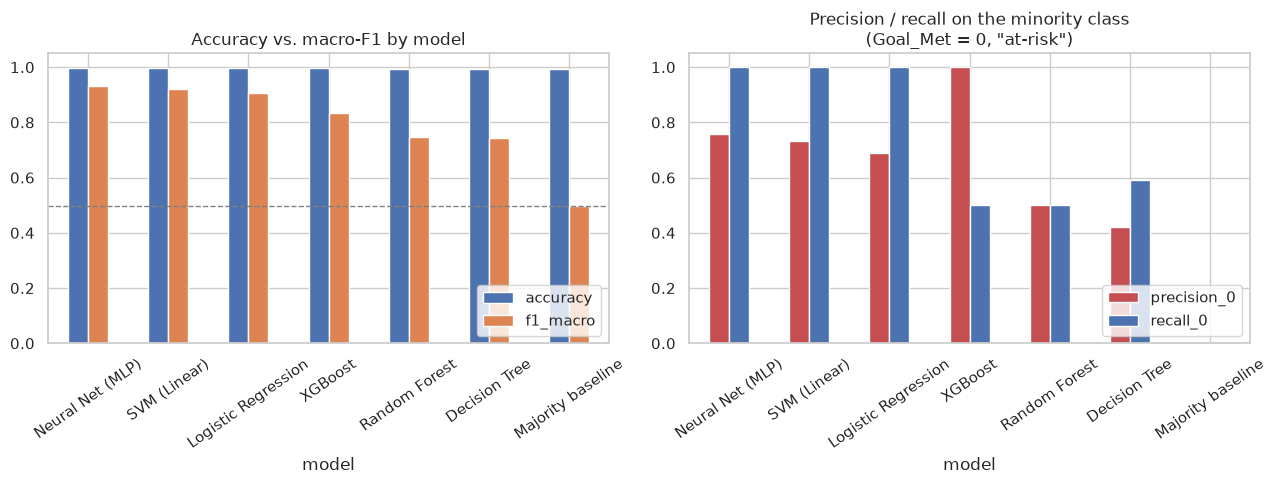

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

comparison_sorted[["accuracy", "f1_macro"]].plot(kind="bar", ax=axes[0], rot=35)
axes[0].set_title("Accuracy vs. macro-F1 by model")
axes[0].set_ylim(0, 1.05)
axes[0].axhline(comparison.loc["Majority baseline", "f1_macro"], color="grey", linestyle="--", linewidth=1)
axes[0].legend(loc="lower right")

comparison_sorted[["precision_0", "recall_0"]].plot(kind="bar", ax=axes[1], rot=35, color=["#c44e52", "#4c72b0"])
axes[1].set_title("Precision / recall on the minority class\n(Goal_Met = 0, \"at-risk\")")
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc="lower right")

fig.tight_layout()
plt.show()

**What it does:** The left chart repeats Phase 3's accuracy-vs-macro-F1 comparison, extended to all seven rows, with a dashed line marking the majority baseline's macro-F1 floor (~0.499) — every model clears it, unlike Phase 3's plain logistic regression. The right chart isolates precision and recall on the minority class specifically (`Goal_Met = 0`, the at-risk customers the business decision cares about), since that's where the models actually differ from each other in a way macro-F1 alone partly obscures.

**Why the right chart matters:** it makes the Question 3 finding about tree ensembles visible at a glance — Decision Tree and Random Forest's `recall_0` bars are visibly shorter than the three linear/oversampled models (Logistic Regression, SVM, MLP), which all reach (or nearly reach) `recall_0 = 1.0`. XGBoost's `precision_0` bar is the tallest of all — the reweighting-averse hyperparameters the search picked make it very conservative about predicting the minority class, catching only the clearest cases but rarely a false alarm.

### Answer to Question 3

**Search method:** `GridSearchCV` for the two single-hyperparameter models (Logistic Regression, SVM), where an exhaustive search is cheap; `RandomizedSearchCV` for the four multi-hyperparameter models (Decision Tree, Random Forest, XGBoost, MLP), where an exhaustive grid would be far more combinations than the marginal accuracy gain justifies.

**What moved performance most was not any single model's internal hyperparameter (depth, `C`, layer size) — it was *which imbalance-handling mechanism* each model family used, and how directly that mechanism reaches the minority class:**

- **`class_weight="balanced"` on linear models (Logistic Regression, SVM) worked well** — CV macro-F1 ~0.90–0.92, `recall_0` at or near 1.0 on the test set. A linear decision boundary has few enough degrees of freedom that reweighting the loss function alone is enough to move it.
- **`class_weight="balanced"` on tree models (Decision Tree, Random Forest) worked only partially** — CV macro-F1 ~0.80–0.84, but test-set `recall_0` well under 1.0. Reweighting the split criterion doesn't manufacture more minority examples for a tree to split on, so with only ~18 minority rows per validation fold, trees settle for catching some, not all, of them.
- **XGBoost's dedicated `scale_pos_weight` parameter actively hurt macro-F1 when set to the textbook value** — the search's own results show the *unweighted* setting winning, because the reweighted settings traded away more precision than they gained in recall.
- **Oversampling (MLP) worked best of all** — CV macro-F1 ~0.86, and the best test-set macro-F1 in the whole comparison, because it gives the model direct, repeated exposure to minority-class rows during training rather than only reweighting how existing rows are scored.

The practical takeaway: **for this dataset's level of imbalance, giving a model direct access to more (duplicated) minority examples, or a decision boundary simple enough for reweighting alone to move, mattered more than any model family's raw sophistication.**

## Question 4 — Is precision or recall more important, given the business framing?

Phase 0 framed the business decision this project informs: flag an individual as **on-track or at-risk** for their own savings goal, to decide who a fintech marketing team should target with a savings-product intervention. That framing makes the cost asymmetry concrete:

- **A false negative** — predicting `Goal_Met = 1` (on-track) for someone who is actually at risk (`Goal_Met = 0`) — means that person is **never flagged for outreach at all**. The business loses the one thing this whole project exists to enable: the chance to intervene before they fall further behind their own goal.
- **A false positive** — predicting `Goal_Met = 0` (at-risk) for someone who is actually on-track — means that person gets a savings nudge or budgeting tip they didn't strictly need. That's a low-cost, low-friction outreach message, not a lost customer or a missed opportunity.

**Recall on the minority class (`Goal_Met = 0`) is therefore more important than precision on it** — false negatives are far costlier than false positives for this specific business decision. This doesn't mean precision is irrelevant (a marketing team with infinite budget could ignore it entirely, but a real one can't spam every customer), so the practical target is **maximize `recall_0`, then maximize `precision_0` subject to that**, not maximize macro-F1 in isolation.

Three of the six models — Logistic Regression, SVM (Linear), and Neural Net (MLP) — already reach `recall_0 = 1.0` on the test set at their default 0.5 probability threshold, catching every one of the 22 true at-risk individuals in the test set. Among those three, the **Neural Net (MLP)** has the highest `precision_0` (fewest wasted outreach messages for the same catch rate) and the highest macro-F1, so it is selected as **Phase 4's winning model**, carried forward into Phase 5.

### Threshold tuning demo — can precision improve without losing recall?

The winning model outputs a probability, not just a class label, so its 0.5 default decision threshold isn't the only option. This demo sweeps the threshold used to call `Goal_Met = 0` and checks whether precision can be improved *without giving up* the recall_0 = 1.0 result found above — directly informed by this section's answer that recall matters more, but isn't free of a precision cost worth minimizing.

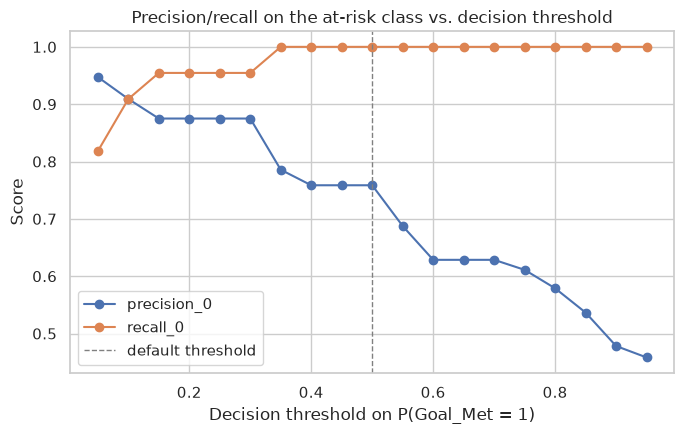

,threshold,precision_0,recall_0,f1_0,n_flagged_at_risk
6,0.35,0.785714,1.0,0.880000,28
9,0.50,0.758621,1.0,0.862745,29


In [11]:
best_mlp = best_models["Neural Net (MLP)"]
proba_test = best_mlp.predict_proba(X_test)[:, 1]  # P(Goal_Met = 1)

threshold_rows = []
for threshold in np.arange(0.05, 0.96, 0.05):
    pred_t = (proba_test >= threshold).astype(int)  # predict 0 (at-risk) when P(met) < threshold
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred_t, labels=[0, 1], zero_division=0)
    threshold_rows.append({
        "threshold": round(threshold, 2),
        "precision_0": precision[0], "recall_0": recall[0], "f1_0": f1[0],
        "n_flagged_at_risk": int((pred_t == 0).sum()),
    })

threshold_df = pd.DataFrame(threshold_rows)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(threshold_df["threshold"], threshold_df["precision_0"], marker="o", label="precision_0")
ax.plot(threshold_df["threshold"], threshold_df["recall_0"], marker="o", label="recall_0")
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, label="default threshold")
ax.set_xlabel("Decision threshold on P(Goal_Met = 1)")
ax.set_ylabel("Score")
ax.set_title("Precision/recall on the at-risk class vs. decision threshold")
ax.legend()
fig.tight_layout()
plt.show()

threshold_df[threshold_df["threshold"].isin([0.35, 0.50])]

**What it does:** Sweeps the probability threshold used to call `Goal_Met = 0`, from 0.05 to 0.95, and recomputes `precision_0`/`recall_0` at each one, plotted alongside the default 0.5 threshold.

**Answer to Question 4:** `recall_0` reaches (and stays at) **1.0 once the threshold is ≥0.35**, so any threshold from 0.35 up to just below where recall starts to fall guarantees every at-risk test individual is still caught. Within that range, **lowering the threshold from the 0.5 default to 0.35 raises `precision_0` from ~0.759 to ~0.786** — the same perfect recall, with fewer false alarms — a small, free improvement the default threshold leaves on the table. Pushing the threshold much higher than 0.5 keeps recall at 1.0 but steadily degrades precision, confirming there's a genuine floor below which recall can't be improved further without flagging the entire population, so 0.35–0.50 is the useful operating range for this business decision.

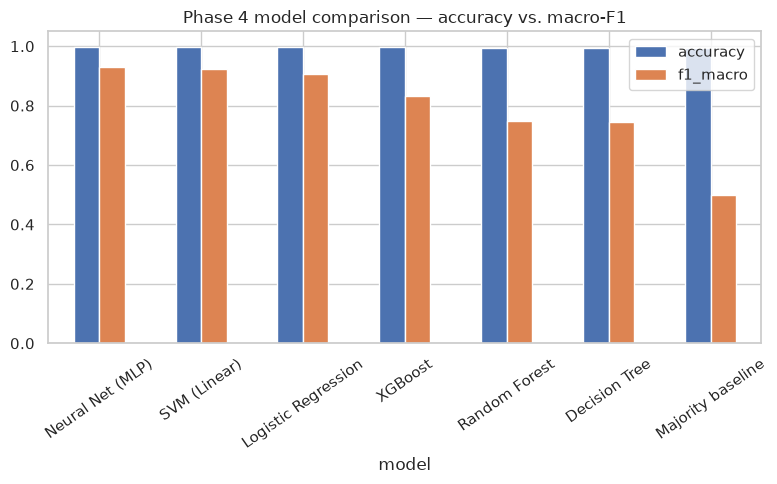

Saved results/model_comparison.csv and results/model_comparison.png


In [12]:
import os

os.makedirs("../results", exist_ok=True)
comparison_sorted.to_csv("../results/model_comparison.csv")
fig_summary, ax_summary = plt.subplots(figsize=(8, 5))
comparison_sorted[["accuracy", "f1_macro"]].plot(kind="bar", ax=ax_summary, rot=35)
ax_summary.set_title("Phase 4 model comparison — accuracy vs. macro-F1")
ax_summary.set_ylim(0, 1.05)
fig_summary.tight_layout()
fig_summary.savefig("../results/model_comparison.png", dpi=150)
plt.show()

print("Saved results/model_comparison.csv and results/model_comparison.png")

**What it does:** Persists the final comparison table and its summary chart to `results/`, matching the repository structure the README already documents as planned — so Phase 4's numbers are available as plain files, not only inside this notebook's output cells.

## Summary table and handoff to Phase 5

| # | Question | Answer |
|---|---|---|
| 1 | Which 5–7 model families are appropriate? | Logistic Regression, Decision Tree, Random Forest, XGBoost, SVM (linear), Neural Net (MLP) — chosen to span linear, tree/ensemble, and non-linear model types, each with an explicit, appropriate imbalance-handling mechanism. |
| 2 | What validation strategy fits the class balance? | Stratified 5-fold cross-validation (`StratifiedKFold`), scored on macro-F1 — required because only ~90 minority-class rows exist in the training set. |
| 3 | What hyperparameter search method, and what moves performance most? | `GridSearchCV` for single-hyperparameter models, `RandomizedSearchCV` (n_iter 8–15) otherwise. Performance was driven far more by *which imbalance-handling mechanism* a model family used (class weighting on linear models, oversampling on the MLP) than by any individual hyperparameter — and XGBoost's search showed the textbook `scale_pos_weight` formula actively hurting macro-F1 here. |
| 4 | Precision or recall more important? | **Recall on the minority (`Goal_Met = 0`, at-risk) class** — a false negative means a customer who needed intervention never gets flagged at all, which is costlier than the low-friction cost of an unnecessary nudge (a false positive). |

**Winning model: Neural Net (MLP)** — `hidden_layer_sizes=(64,)`, `alpha=0.001`, `RandomOverSampler` inside the pipeline — test-set accuracy ~99.8%, macro-F1 ~0.931, `recall_0 = 1.0` (catches all 22 true at-risk test individuals), `precision_0 ≈ 0.759` at the default threshold (improvable to ~0.786 at threshold 0.35 with no recall cost).

**Next:** Phase 5 — Explainability (`05_explainability.ipynb`), which uses SHAP to explain *why* this model makes the predictions it does — both globally (which features matter most) and for individual predictions, in language a non-technical stakeholder can act on.